# Battery 불량 탐지 - Custom CNN (로컬 버전)

**목표**: 배터리 이미지를 `normal(정상)` / `defect(불량)` 으로 이진 분류합니다.

**모델**: 직접 설계한 Custom CNN (Convolutional Neural Network)

**환경**: 로컬 Windows 환경에서 실행 가능하도록 Kaggle 경로를 수정했습니다.

---
### 데이터셋 구조
```
dataset/
  battery_subset_binary_train10000/
    train.csv
    valid.csv
    images/
      normal/
      defect/
```

> **메모리 절약 방식**: 이 노트북은 이미지를 RAM에 한꺼번에 올리지 않고,
> `tf.data` 파이프라인으로 배치 단위로 읽습니다. 덕분에 RAM 부족 에러 없이 실행됩니다.

In [1]:
# ==============================================================
# [셀 1] 라이브러리 임포트 및 경로 설정
# ==============================================================
# os     : 파일/폴더 경로 조작 (경로 합치기, 폴더 생성 등)
# pandas : CSV 파일을 표(DataFrame) 형태로 읽고 조작
# glob   : 특정 패턴에 맞는 파일 목록을 와일드카드로 검색
# ==============================================================

import os
import pandas as pd
from glob import glob

# [로컬 수정] Kaggle: '/dataset/...' -> 로컬: './dataset/...'
# os.getcwd() 는 현재 작업 디렉토리(노트북이 있는 폴더)를 반환합니다.
ROOT = os.path.join(os.getcwd(), 'dataset', 'battery_subset_binary_train10000')
IMAGE_DIR = os.path.join(ROOT, 'images')

print('데이터셋 루트 경로:', ROOT)
print('이미지 폴더 경로:', IMAGE_DIR)

# 이미지 파일 목록 수집 (대소문자 확장자 모두 포함)
# glob의 recursive=True: 하위 폴더까지 재귀 탐색
image_files = []
for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.PNG', '*.JPG', '*.JPEG', '*.BMP']:
    image_files.extend(glob(os.path.join(IMAGE_DIR, '**', ext), recursive=True))

print('\n전체 이미지 개수:', len(image_files))
print('이미지 예시 (첫 3개):')
print(image_files[:3])

print('\ndefect 이미지 개수:', len(glob(os.path.join(IMAGE_DIR, 'defect', '*'))))
print('normal 이미지 개수:', len(glob(os.path.join(IMAGE_DIR, 'normal', '*'))))

데이터셋 루트 경로: d:\DeepLearning\dataset\battery_subset_binary_train10000
이미지 폴더 경로: d:\DeepLearning\dataset\battery_subset_binary_train10000\images

전체 이미지 개수: 20000
이미지 예시 (첫 3개):
['d:\\DeepLearning\\dataset\\battery_subset_binary_train10000\\images\\defect\\Damaged_000017_RGB_cell_cylindrical_0408_029.png', 'd:\\DeepLearning\\dataset\\battery_subset_binary_train10000\\images\\defect\\Damaged_000019_RGB_cell_cylindrical_0319_196.png', 'd:\\DeepLearning\\dataset\\battery_subset_binary_train10000\\images\\defect\\Damaged_000020_RGB_cell_cylindrical_0145_125.png']

defect 이미지 개수: 5000
normal 이미지 개수: 5000


In [2]:
# ==============================================================
# [셀 2] CSV 파일 로드 및 컬럼 확인
# ==============================================================
# train.csv : 학습에 사용할 이미지 경로와 라벨 목록
# valid.csv : 학습 중 성능 검증에 사용할 데이터 목록
#
# 학습/검증 분리 이유:
#   - 학습 데이터만으로 평가하면 과적합(overfitting) 여부를 알 수 없음
#   - 모델이 본 적 없는 검증 데이터 성능 = 실제 일반화 성능
# ==============================================================

TRAIN_CSV = os.path.join(ROOT, 'train.csv')
VALID_CSV  = os.path.join(ROOT, 'valid.csv')

train_df = pd.read_csv(TRAIN_CSV)
valid_df  = pd.read_csv(VALID_CSV)

print('=== train.csv ===')
print('컬럼:', train_df.columns.tolist())
print('행 수:', len(train_df))
print(train_df.head())

print('\n=== valid.csv ===')
print('컬럼:', valid_df.columns.tolist())
print('행 수:', len(valid_df))
print(valid_df.head())

=== train.csv ===
컬럼: ['split', 'image_file', 'image_path', 'json_path', 'is_normal', 'binary_label', 'main_defect', 'defect_names', 'defect_count', 'new_image_path', 'new_relative_path', 'new_image_file']
행 수: 8000
   split                         image_file  \
0  train  RGB_cell_cylindrical_1137_233.png   
1  train  RGB_cell_cylindrical_0205_012.png   
2  train  RGB_cell_cylindrical_0251_031.png   
3  train  RGB_cell_cylindrical_0510_223.png   
4  train  RGB_cell_cylindrical_1132_291.png   

                                          image_path  \
0  D:\DL_dataset\103.배터리 불량 이미지 데이터\3.개방데이터\datas...   
1  D:\DL_dataset\103.배터리 불량 이미지 데이터\3.개방데이터\datas...   
2  D:\DL_dataset\103.배터리 불량 이미지 데이터\3.개방데이터\datas...   
3  D:\DL_dataset\103.배터리 불량 이미지 데이터\3.개방데이터\datas...   
4  D:\DL_dataset\103.배터리 불량 이미지 데이터\3.개방데이터\datas...   

                                           json_path  is_normal binary_label  \
0  D:\DL_dataset\103.배터리 불량 이미지 데이터\3.개방데이터\datas...       True       normal   
1  D

In [3]:
# ==============================================================
# [셀 3] 이미지 경로 생성 + 유효성 검증
# ==============================================================
# 데이터셋에 0바이트 빈 파일이 21개 존재합니다.
# (train 18개, valid 3개)
#
# 빈 파일이 tf.data 파이프라인에 들어가면
# 'Input is empty' 에러가 발생하므로 반드시 제외해야 합니다.
#
# 검증 방법: os.path.getsize() > 0 (파일 크기 확인)
# -> 1초 내로 완료됩니다!
# ==============================================================

# 경로 구분자 통일
train_df['new_relative_path'] = train_df['new_relative_path'].str.replace('\\', '/', regex=False)
valid_df['new_relative_path'] = valid_df['new_relative_path'].str.replace('\\', '/', regex=False)

# 로컬 절대 경로 생성
train_df['image_path'] = train_df['new_relative_path'].apply(lambda x: os.path.join(ROOT, x))
valid_df['image_path'] = valid_df['new_relative_path'].apply(lambda x: os.path.join(ROOT, x))

# 유효성 검증: 파일 존재 + 크기 > 0
# (0바이트 빈 파일은 이미지가 아니므로 제외)
def is_valid_file(path):
    return os.path.exists(path) and os.path.getsize(path) > 0

train_df['image_valid'] = train_df['image_path'].apply(is_valid_file)
valid_df['image_valid'] = valid_df['image_path'].apply(is_valid_file)

# 검증 결과 출력
train_bad = len(train_df) - train_df['image_valid'].sum()
valid_bad = len(valid_df) - valid_df['image_valid'].sum()

print(f"train 유효: {train_df['image_valid'].sum()} / {len(train_df)} (제외: {train_bad}장)")
print(f"valid 유효: {valid_df['image_valid'].sum()} / {len(valid_df)} (제외: {valid_bad}장)")

print('\ntrain 라벨 분포')
print(train_df['binary_label'].value_counts())
print('\nvalid 라벨 분포')
print(valid_df['binary_label'].value_counts())

# 유효한 이미지만 필터링
train_df = train_df[train_df['image_valid']].copy()
valid_df = valid_df[valid_df['image_valid']].copy()

print(f'\n최종: train {len(train_df)}장, valid {len(valid_df)}장')


train 유효: 7982 / 8000 (제외: 18장)
valid 유효: 1997 / 2000 (제외: 3장)

train 라벨 분포
binary_label
normal    4000
defect    4000
Name: count, dtype: int64

valid 라벨 분포
binary_label
defect    1000
normal    1000
Name: count, dtype: int64

최종: train 7982장, valid 1997장


In [4]:
# ==============================================================
# [셀 4] tf.data 파이프라인으로 데이터셋 구성
# ==============================================================
# [메모리 문제 해결] 기존 방식 vs 개선 방식 비교
#
#  기존 방식 (MemoryError 발생):
#    X_train, y_train = load_images(train_df)  # 전부 RAM에 올림
#    -> 7982 x 224 x 224 x 3 x 4바이트 = 4.48 GB 필요 -> 에러!
#
#  개선 방식 (tf.data 파이프라인):
#    - 이미지 경로 목록만 메모리에 유지
#    - 학습 중 배치 단위(16장)로만 디스크에서 읽음
#    - 메모리 사용량: ~9 MB 만 사용!
#    - prefetch: CPU가 학습 중에 미리 다음 배치를 준비 (속도 향상)
#
# tf.data 파이프라인 구성 순서:
#   1. from_tensor_slices() : 경로+라벨 쌍의 스트림 생성
#   2. .map(전처리 함수)    : 각 항목에 이미지 읽기/전처리 적용
#   3. .shuffle()           : 에포크마다 순서 섞기 (과적합 방지)
#   4. .batch(BATCH_SIZE)   : 배치 단위로 묶기
#   5. .prefetch()          : 다음 배치 미리 준비
# ==============================================================

import numpy as np
import tensorflow as tf

IMG_SIZE   = 224
BATCH_SIZE = 16

# 라벨 문자열 -> 숫자 변환
train_df['label_num'] = train_df['binary_label'].map({'normal': 0, 'defect': 1})
valid_df['label_num'] = valid_df['binary_label'].map({'normal': 0, 'defect': 1})

# 경로 리스트와 라벨 리스트 추출
train_paths  = train_df['image_path'].tolist()
train_labels = train_df['label_num'].tolist()
valid_paths  = valid_df['image_path'].tolist()
valid_labels = valid_df['label_num'].tolist()


def load_and_preprocess(path, label):
    """
    tf.data 파이프라인에서 호출되는 이미지 전처리 함수.
    TensorFlow 연산만 사용 -> GPU/병렬 처리 가능.
    """
    # 1. 디스크에서 이미지 파일을 바이트로 읽기
    raw = tf.io.read_file(path)

    # 2. JPEG/PNG/BMP 등 자동 디코딩 -> (H, W, 3) uint8 텐서
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)

    # 3. shape을 명시적으로 설정 (decode_image는 shape이 None일 수 있음)
    img.set_shape([None, None, 3])

    # 4. 224x224로 리사이즈
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    # 5. 픽셀값 0~255 -> 0.0~1.0 정규화
    img = tf.cast(img, tf.float32) / 255.0

    return img, label


# train 데이터셋: shuffle 적용 (에포크마다 순서를 섞어 과적합 방지)
train_dataset = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .shuffle(buffer_size=len(train_paths), seed=42)
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# valid 데이터셋: shuffle 불필요
valid_dataset = (
    tf.data.Dataset.from_tensor_slices((valid_paths, valid_labels))
    .shuffle(buffer_size=len(train_paths), seed=42)
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# 배치 1개 꺼내서 형태 확인 (실제로 잘 로드되는지 테스트)
sample_images, sample_labels = next(iter(train_dataset))
print('샘플 배치 이미지 shape:', sample_images.shape)   # (16, 224, 224, 3)
print('샘플 배치 라벨:', sample_labels.numpy())
print('픽셀값 범위:', f'{sample_images.numpy().min():.2f} ~ {sample_images.numpy().max():.2f}')

print(f'\ntrain: {len(train_paths)}장 | valid: {len(valid_paths)}장')
print(f'배치 수 (train): {len(train_dataset)} | 배치 수 (valid): {len(valid_dataset)}')


샘플 배치 이미지 shape: (16, 224, 224, 3)
샘플 배치 라벨: [1 1 0 1 0 1 1 1 0 0 1 1 1 1 0 1]
픽셀값 범위: 0.00 ~ 1.00

train: 7982장 | valid: 1997장
배치 수 (train): 499 | 배치 수 (valid): 125


In [5]:
# ==============================================================
# [셀 5] 클래스 분포 확인
# ==============================================================
# 클래스 불균형(Class Imbalance) 이란?
#   - normal과 defect 이미지 수가 크게 차이나면
#     모델이 많은 쪽만 예측하는 경향이 생깁니다.
#   - 예: defect가 1%, normal이 99%이면
#     모두 normal로 예측해도 정확도 99%가 나옴!
#   - 불균형이 심하면 class_weight 옵션이나 오버샘플링 필요
# ==============================================================

train_labels_arr = np.array(train_labels)
valid_labels_arr  = np.array(valid_labels)

print('=== train 클래스 분포 ===')
print('normal (0):', np.sum(train_labels_arr == 0))
print('defect  (1):', np.sum(train_labels_arr == 1))
print(f'비율: normal={np.mean(train_labels_arr==0):.1%}, defect={np.mean(train_labels_arr==1):.1%}')

print('\n=== valid 클래스 분포 ===')
print('normal (0):', np.sum(valid_labels_arr == 0))
print('defect  (1):', np.sum(valid_labels_arr == 1))
print(f'비율: normal={np.mean(valid_labels_arr==0):.1%}, defect={np.mean(valid_labels_arr==1):.1%}')

=== train 클래스 분포 ===
normal (0): 4000
defect  (1): 3982
비율: normal=50.1%, defect=49.9%

=== valid 클래스 분포 ===
normal (0): 1000
defect  (1): 997
비율: normal=50.1%, defect=49.9%


In [6]:
# ==============================================================
# [셀 6] Custom CNN 모델 정의 및 학습
# ==============================================================
# CNN(Convolutional Neural Network) 구조 설명:
#
#  [Conv2D] 합성곱 레이어
#    - 이미지에서 특징(엣지, 텍스처, 패턴 등)을 추출합니다.
#    - filters=32  : 32가지 다른 특징을 동시에 탐지
#    - kernel=(3,3): 3x3 픽셀 영역을 보며 특징 추출 (슬라이딩 윈도우)
#    - relu        : 음수는 0, 양수는 그대로 (비선형성 부여)
#
#  [MaxPooling2D] 최대 풀링
#    - 특징 맵을 절반 크기로 줄입니다 (계산량 감소, 위치 불변성 확보)
#    - (2,2): 2x2 영역에서 가장 큰 값만 남김
#
#  [Flatten] 펼치기
#    - 2D 특징 맵 -> 1D 벡터로 변환 (Dense 레이어 연결용)
#
#  [Dense] 완전 연결 레이어 (Fully Connected Layer)
#    - 추출된 특징을 조합하여 최종 판단
#
#  [Dropout(0.5)] 드롭아웃
#    - 과적합 방지: 학습 중 50%의 뉴런을 무작위로 끔
#    - 예측 시에는 모든 뉴런 사용 (자동 처리됨)
#
#  [Dense(1, sigmoid)] 출력 레이어
#    - sigmoid: 0~1 사이 확률값 출력
#    - 0.5 이상 -> defect, 미만 -> normal
# ==============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# [로컬 수정] Kaggle: '/kaggle/working/model' -> 로컬: './model'
MODEL_DIR = os.path.join(os.getcwd(), 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

EPOCHS = 10   # 전체 데이터를 몇 번 반복 학습할지

# -- 모델 구조 정의 --
model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),  # 입력: (224, 224, 3) RGB 이미지

    # 1번째 Conv 블록: 간단한 엣지/색상 패턴 탐지
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # 2번째 Conv 블록: 더 복잡한 패턴 (선, 곡선 등)
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # 3번째 Conv 블록: 고수준 특징 (형태, 구조 등)
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),                         # 2D -> 1D 변환
    Dense(128, activation='relu'),     # 분류기: 특징 조합
    Dropout(0.5),                      # 과적합 방지
    Dense(1, activation='sigmoid')     # 최종 출력: defect 확률 (0~1)
])

# -- 모델 컴파일 --
# optimizer Adam   : 학습률을 자동으로 조절하는 최적화 알고리즘
# loss binary_xent : 이진 분류의 표준 손실 함수
# metrics accuracy : 정확도 (맞힌 개수 / 전체 개수)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()  # 모델 구조 출력 (레이어, 파라미터 수 확인)

# -- 콜백 정의 --
# ModelCheckpoint: 검증 정확도가 가장 높을 때 자동 저장
checkpoint = ModelCheckpoint(
    os.path.join(MODEL_DIR, 'battery_cnn_local_best.keras'),
    monitor='val_accuracy',   # 검증 정확도 기준
    save_best_only=True,
    mode='max',
    verbose=1
)

# EarlyStopping: 검증 손실이 3번 연속 개선 없으면 조기 종료
# (과적합 방지 + 시간 절약)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,                # 3 에포크 동안 개선 없으면 중단
    restore_best_weights=True  # 최적 가중치로 복원
)

# -- 학습 시작 --
# [변경] X_train 대신 train_dataset (tf.data) 사용
# -> 배치 단위로 디스크에서 읽으므로 RAM 부족 없음!
history = model.fit(
    train_dataset,              # tf.data 파이프라인 (배치 포함)
    validation_data=valid_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
    # batch_size는 이미 dataset에 포함되어 있으므로 생략
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.8966 - loss: 0.2473
Epoch 1: val_accuracy improved from -inf to 0.98247, saving model to d:\DeepLearning\model\battery_cnn_local_best.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 327s 648ms/step - accuracy: 0.8968 - loss: 0.2471 - val_accuracy: 0.9825 - val_loss: 0.0695
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9838 - loss: 0.0771
Epoch 2: val_accuracy did not improve from 0.98247
499/499 ━━━━━━━━━━━━━━━━━━━━ 293s 587ms/step - accuracy: 0.9838 - loss: 0.0771 - val_accuracy: 0.9825 - val_loss: 0.0674
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9867 - loss: 0.0641
Epoch 3: val_accuracy improved from 0.98247 to 0.98448, saving model to d:\DeepLearning\model\battery_cnn_local_best.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 293s 587ms/step - accuracy: 0.9867 - loss: 0.0641 - val_accuracy: 0.9845 - val_loss: 0.0839
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9870 - loss

In [11]:
# ==============================================================
# [셀 7] 모델 평가 - Confusion Matrix & Classification Report
# ==============================================================
# Confusion Matrix (혼동 행렬) 읽는 법:
#
#                    예측:normal  예측:defect
#   실제: normal  [  TN(정답)     FP(오경보)  ]
#   실제: defect  [  FN(누락)     TP(정답)    ]
#
#   TN: 정상을 정상으로 올바르게 예측
#   TP: 불량을 불량으로 올바르게 예측
#   FP: 정상인데 불량으로 잘못 예측 (오경보)
#   FN: 불량인데 정상으로 잘못 예측 <- 가장 위험!
#
# Classification Report 지표:
#   Precision(정밀도): 불량이라 예측한 것 중 실제 불량 비율
#   Recall(재현율)  : 실제 불량 중 올바르게 탐지한 비율
#   F1-score        : Precision과 Recall의 조화 평균
# ==============================================================

from sklearn.metrics import confusion_matrix, classification_report

# tf.data 파이프라인 기반 평가
loss, acc = model.evaluate(valid_dataset)
print('\n검증 손실 (Loss):', round(loss, 4))
print('검증 정확도 (Accuracy):', round(acc, 4))

# 예측값 수집: 배치별로 예측 후 합치기
y_prob_list = []
y_true_list = []

for batch_images, batch_labels in valid_dataset:
    preds = model.predict_on_batch(batch_images)  # 배치 단위 예측
    y_prob_list.append(preds.reshape(-1))
    y_true_list.append(batch_labels.numpy())

y_prob = np.concatenate(y_prob_list)   # 전체 예측 확률
y_true = np.concatenate(y_true_list)   # 전체 실제 라벨
y_pred = (y_prob >= 0.5).astype(int)   # 0.5 기준 이진 분류

print('\n=== Confusion Matrix ===')
print(confusion_matrix(y_true, y_pred))

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['normal', 'defect']))

125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - accuracy: 0.9853 - loss: 0.0447

검증 손실 (Loss): 0.049
검증 정확도 (Accuracy): 0.9845

=== Confusion Matrix ===
[[969  31]
 [  0 997]]

=== Classification Report ===
              precision    recall  f1-score   support

      normal       1.00      0.97      0.98      1000
      defect       0.97      1.00      0.98       997

    accuracy                           0.98      1997
   macro avg       0.98      0.98      0.98      1997
weighted avg       0.98      0.98      0.98      1997



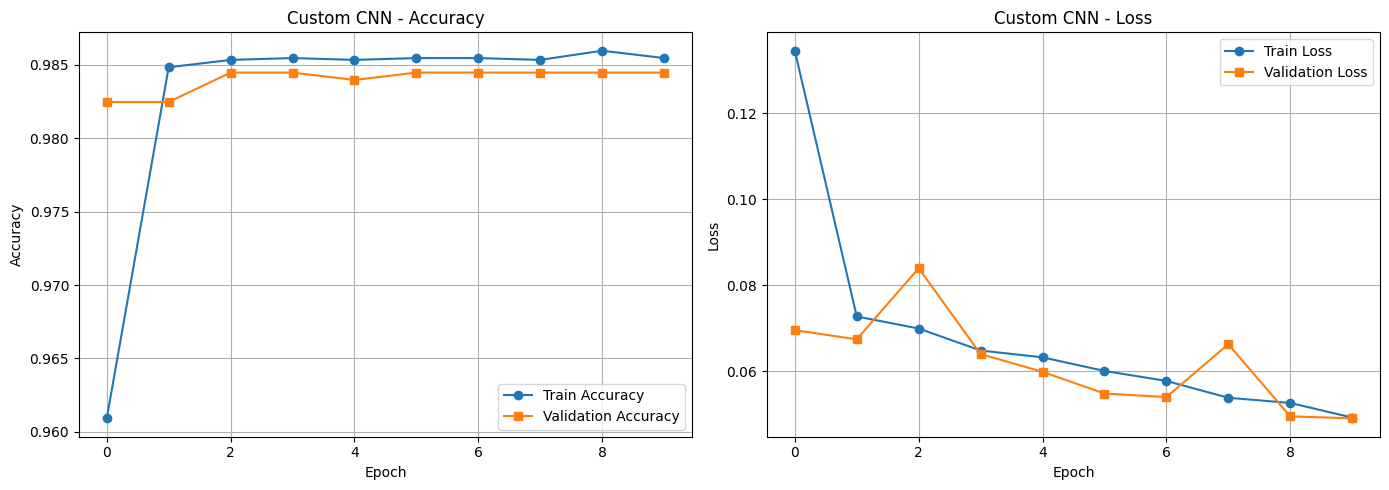

학습 곡선 저장: d:\DeepLearning\model\cnn_training_curve.png


In [13]:
# ==============================================================
# [셀 8] 학습 곡선 시각화
# ==============================================================
# 학습 곡선으로 확인할 점:
#
#  정상적인 학습:
#    - train/val 정확도가 함께 올라가고 비슷한 수준 유지
#    - train/val 손실이 함께 내려감
#
#  과적합(Overfitting) 징후:
#    - train 정확도는 올라가지만 val 정확도는 정체/하락
#    - train 손실은 줄지만 val 손실은 올라감 (갈라짐)
#
#  과소적합(Underfitting) 징후:
#    - 둘 다 낮은 정확도, 수렴하지 못하고 진동
# ==============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Custom CNN - Accuracy'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Custom CNN - Loss'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'cnn_training_curve.png'), dpi=150)
plt.show()
print('학습 곡선 저장:', os.path.join(MODEL_DIR, 'cnn_training_curve.png'))

In [14]:
# ==============================================================
# [셀 9] 모델 저장
# ==============================================================
# Keras 모델 저장 형식:
#   .keras : 최신 Keras 3 형식 (권장). 구조+가중치+설정 모두 포함
#   .h5    : 구형 HDF5 형식 (레거시 호환용)
#
# 저장된 모델 불러오기:
#   from tensorflow.keras.models import load_model
#   model = load_model('model/battery_cnn_local_final.keras')
# ==============================================================

save_path = os.path.join(MODEL_DIR, 'battery_cnn_local_final.keras')
model.save(save_path)
print('최종 모델 저장 완료:', save_path)
print('(학습 중 최적 모델은 battery_cnn_local_best.keras 에 이미 저장됨)')

최종 모델 저장 완료: d:\DeepLearning\model\battery_cnn_local_final.keras
(학습 중 최적 모델은 battery_cnn_local_best.keras 에 이미 저장됨)


In [ ]:
# ==============================================================
# [셀 10] 오분류 샘플 분석
# ==============================================================
# 오분류 분석의 중요성:
#   - 어떤 이미지를 틀렸는지 확인하면 모델의 약점 파악 가능
#   - FN(불량을 정상으로 예측)이 실제 산업에서 가장 위험
#   - defect_probability로 모델이 얼마나 확신하고 틀렸는지 확인
#
# [셀 7]에서 이미 y_prob, y_true, y_pred를 수집했으므로 바로 사용합니다.
# ==============================================================

# valid_df와 예측 결과 합치기
# (셀 7에서 valid_dataset은 shuffle 없으므로 순서가 valid_df와 일치)
result_df = valid_df.copy().reset_index(drop=True)
result_df['true_label_num']     = y_true.astype(int)
result_df['pred_label_num']     = y_pred.astype(int)
result_df['defect_probability'] = y_prob

result_df['true_label'] = result_df['true_label_num'].map({0: 'normal', 1: 'defect'})
result_df['pred_label'] = result_df['pred_label_num'].map({0: 'normal', 1: 'defect'})

# 오분류만 필터링
wrong_df = result_df[
    result_df['true_label_num'] != result_df['pred_label_num']
].copy()

print('전체 검증 이미지:', len(result_df))
print('오분류 개수:', len(wrong_df))
print(f'오분류율: {len(wrong_df)/len(result_df):.1%}')

# FN (불량을 정상으로 예측) 분리 <- 가장 위험
fn_df = wrong_df[wrong_df['true_label'] == 'defect']
fp_df = wrong_df[wrong_df['true_label'] == 'normal']
print(f'FN (불량->정상 오분류): {len(fn_df)}건')
print(f'FP (정상->불량 오분류): {len(fp_df)}건')

display_cols = ['new_image_file', 'true_label', 'pred_label', 'defect_probability']
if 'main_defect' in wrong_df.columns:
    display_cols.append('main_defect')

print('\n오분류 샘플 (상위 5개):')
print(wrong_df[display_cols].head())

전체 검증 이미지: 1997
오분류 개수: 31
오분류율: 1.6%
FN (불량->정상 오분류): 0건
FP (정상->불량 오분류): 31건

오분류 샘플 (상위 5개):
                                        new_image_file true_label pred_label  \
51   Pollution_007782_RGB_cell_cylindrical_0418_154...     normal     defect   
103    normal_002146_RGB_cell_cylindrical_1096_099.png     normal     defect   
297    normal_001947_RGB_cell_cylindrical_1098_054.png     normal     defect   
299  Pollution_001864_RGB_cell_cylindrical_0503_122...     normal     defect   
421    normal_009828_RGB_cell_cylindrical_1048_069.png     normal     defect   

     defect_probability main_defect  
51             0.883833   Pollution  
103            0.836196      normal  
297            0.604288      normal  
299            0.684908   Pollution  
421            0.835036      normal  


: 